# Import Libraries

In [1]:
import pandas as pd
import numpy as np

# Import Data

In [2]:
transactions = pd.read_csv("../data/transactions_2016_2017.csv")
train = pd.read_csv("../data/customer_clv_train.csv")
test = pd.read_csv("../data/customer_clv_test.csv")

/var/folders/3m/cw1m5lkx3ml5zf_qkrwvpxph0000gn/T/ipykernel_48430/3514003606.py:1: DtypeWarning: Columns (0: prod_size) have mixed types. Specify dtype option on import or set low_memory=False.
  transactions = pd.read_csv("../data/transactions_2016_2017.csv")


# EDA

In [3]:
transactions.shape, train.shape, test.shape

((344212, 26), (116591, 2), (29148, 1))

In [4]:
#Number of unique customers in transactions
print(transactions["cust_id"].nunique())
#Number of unique customers in TRAIN
print(train["cust_id"].nunique())
#Number of unique customers in TEST
print(test["cust_id"].nunique())
#check if all customers in train and test are in transactions
print(train["cust_id"].isin(transactions["cust_id"]).all())
print(test["cust_id"].isin(transactions["cust_id"]).all())  

145739
116591
29148
True
True


## Examine Revenue

In [5]:
#Target distribution
train["revenue_2018_2019"].describe()

count    116591.000000
mean         70.364667
std         144.303602
min           0.000000
25%           0.000000
50%           0.000000
75%          80.960000
max        1197.940000
Name: revenue_2018_2019, dtype: float64

In [6]:
#Percent of customers with zero revenue"
(train["revenue_2018_2019"] == 0).mean()

np.float64(0.6341227024384386)

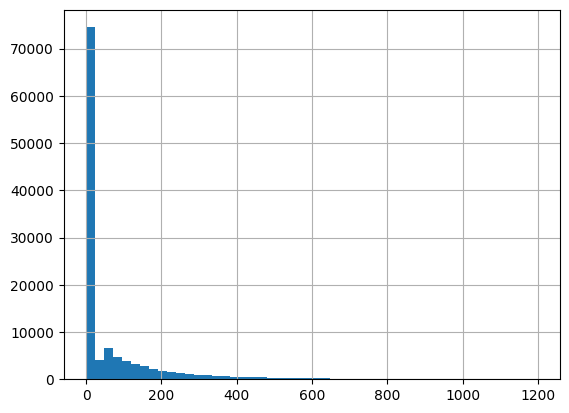

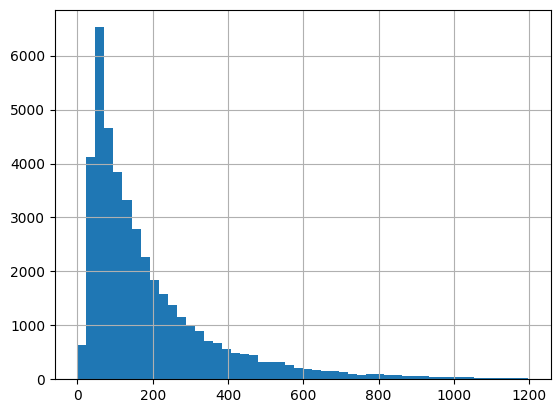

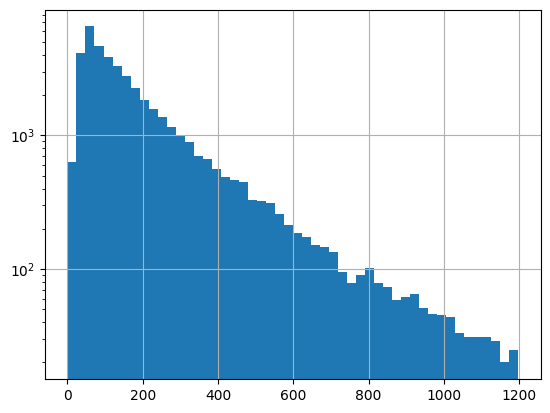

In [7]:
#plot distribution of target variable
import matplotlib.pyplot as plt

train["revenue_2018_2019"].hist(bins=50)
plt.show()

#plot distribution of target variable with no zero values
train[train["revenue_2018_2019"] > 0]["revenue_2018_2019"].hist(bins=50)
plt.show()  

#plot distribution of target variable with log scale with no zero values
train[train["revenue_2018_2019"] > 0]["revenue_2018_2019"].hist(bins=50, log=True)
plt.show()  

Large zero return (>60%), hence two part modelling strategy- first predict returning customer, then within those, predicting future revenue. predicting on the log of the revenue and then back converting. Next step, creating a customer feature table from transcations. first inspect and clean transactions

## Examine Transactions features

In [8]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 344212 entries, 0 to 344211
Data columns (total 26 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   cust_id                344212 non-null  str    
 1   order_date             344212 non-null  str    
 2   pack_date              344212 non-null  str    
 3   sale_id                344212 non-null  str    
 4   sale_discount_applied  344212 non-null  float64
 5   sale_revenue           344212 non-null  float64
 6   returned_to_shop_id    63930 non-null   str    
 7   prod_id                344212 non-null  str    
 8   prod_size              344212 non-null  object 
 9   prod_web_only          344212 non-null  int64  
 10  prod_season            344212 non-null  str    
 11  prod_brand             344212 non-null  str    
 12  prod_title             344212 non-null  str    
 13  prod_color             344212 non-null  str    
 14  prod_type_1            344212 non-null  str    

In [9]:
transactions["order_date"] = pd.to_datetime(transactions["order_date"])
transactions["pack_date"] = pd.to_datetime(transactions["pack_date"])

In [10]:
transactions["order_date"].min(), transactions["order_date"].max()

(Timestamp('2016-01-01 00:00:00'), Timestamp('2017-12-31 00:00:00'))

In [11]:
transactions.isna().sum().sort_values(ascending=False)

prod_comfort_wear        311691
prod_comfort_sole        302073
returned_to_shop_id      280282
prod_print               266742
prod_type_4              201753
prod_heel                132201
prod_clasp                38655
prod_insole               25965
prod_material             22741
prod_type_5                6260
cust_id                       0
prod_type_1                   0
prod_type_3                   0
prod_color                    0
order_date                    0
prod_title                    0
prod_brand                    0
prod_season                   0
prod_web_only                 0
prod_size                     0
prod_id                       0
sale_revenue                  0
sale_discount_applied         0
sale_id                       0
pack_date                     0
prod_outlet                   0
dtype: int64

In [12]:
print("prod_season: ",transactions["prod_season"].nunique())
print("prod_brand: ",transactions["prod_brand"].nunique())
print("prod_title: ",transactions["prod_title"].nunique())
print("prod_color: ",transactions["prod_color"].nunique())
print("prod_type_1: ",transactions["prod_type_1"].nunique())
print("prod_type_3: ",transactions["prod_type_3"].nunique())
print("prod_type_4: ",transactions["prod_type_4"].nunique())
print("prod_type_5: ",transactions["prod_type_5"].nunique())
print("prod_heel: ",transactions["prod_heel"].nunique())
print("prod_material: ",transactions["prod_material"].nunique())
print("prod_print: ",transactions["prod_print"].nunique())
print("prod_comfort_wear: ",transactions["prod_comfort_wear"].nunique())
print("prod_clasp: ",transactions["prod_clasp"].nunique())

prod_season:  23
prod_brand:  493
prod_title:  21302
prod_color:  41
prod_type_1:  4
prod_type_3:  41
prod_type_4:  48
prod_type_5:  51
prod_heel:  4
prod_material:  58
prod_print:  128
prod_comfort_wear:  13
prod_clasp:  48


In [13]:
transactions.groupby("sale_id").size().describe()


count    245928.000000
mean          1.399645
std           0.852768
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          28.000000
dtype: float64

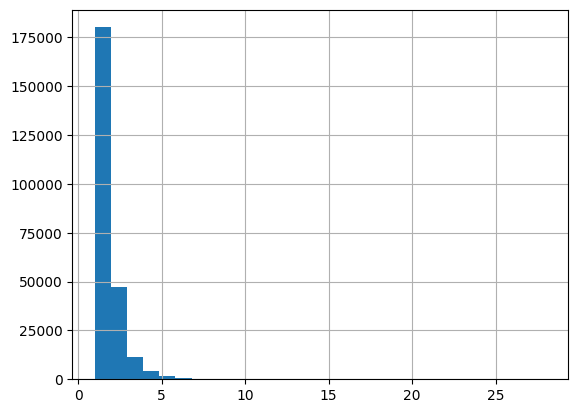

<Axes: >

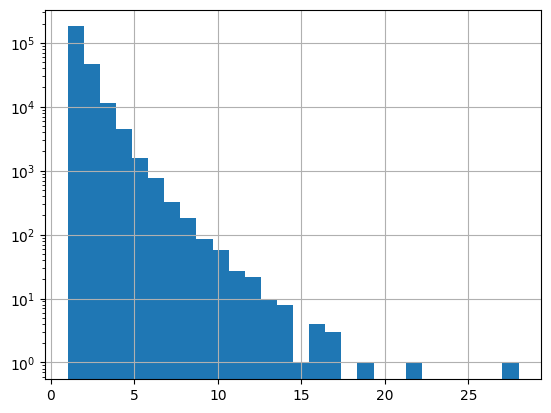

In [14]:

#plot distribution of sale cardinalities
import matplotlib.pyplot as plt

transactions.groupby("sale_id").size().hist(bins=28)
plt.show()

#plot distribution of sale cardinalities with log scale
transactions.groupby("sale_id").size().hist(bins=28, log=True)

In [15]:
transactions["sale_revenue"].describe()

count    344212.000000
mean         53.074974
std          38.108857
min        -200.000000
25%          27.000000
50%          53.000000
75%          75.950000
max         275.000000
Name: sale_revenue, dtype: float64

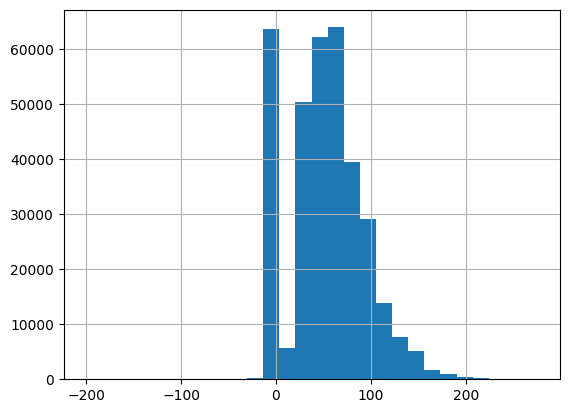

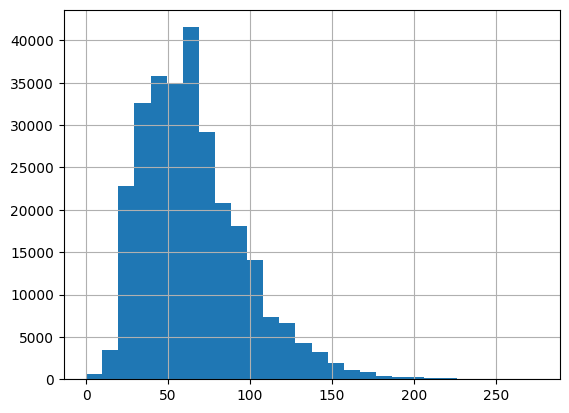

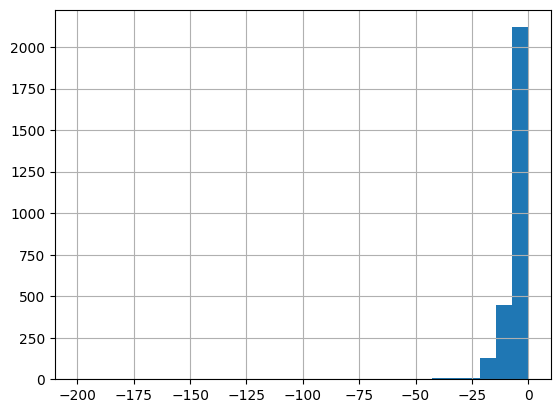

In [16]:
transactions["sale_revenue"].hist(bins=28)
plt.show()

#plot distribution of positive sale revenue
transactions[transactions["sale_revenue"] > 0]["sale_revenue"].hist(bins=28)
plt.show()

#plot distribution of negative sale revenue
transactions[transactions["sale_revenue"] < 0]["sale_revenue"].hist(bins=28)
plt.show()

In [17]:
#return rate
transactions["returned_to_shop_id"].notna().mean()

np.float64(0.1857285626300071)

In [18]:
#discount summary
transactions["sale_discount_applied"].describe()

count    344212.000000
mean        -20.646063
std          22.479681
min        -200.000000
25%         -31.500000
50%         -12.000000
75%          -4.590000
max           1.000000
Name: sale_discount_applied, dtype: float64

In [19]:
# percentage of sale discount non zero 
(transactions["sale_discount_applied"] != 0).mean()

np.float64(0.8003091118264325)

In [20]:
neg_rev = transactions[transactions["sale_revenue"] < 0]

neg_rev["returned_to_shop_id"].notna().mean()

np.float64(0.9981658107116654)

In [21]:
transactions.loc[
    (transactions["sale_revenue"] < 0) &
    (transactions["returned_to_shop_id"].isna()),
    "sale_id"
]

23123     4xudgwbqiyllapva
34367     srend6kslav2dnfu
75718     dyhlcay7urfd747w
75719     dyhlcay7urfd747w
160031    fl6lhwmbqce25p72
Name: sale_id, dtype: str

strange entries- these 5 (2 from the same order) have a negative sales revenue but are not related to a return... statistically insigificant, so will leave as is.  

In [22]:
transactions[
    (transactions["returned_to_shop_id"].notna()) &
    (transactions["sale_revenue"] > 0)
].shape

(391, 26)

In [23]:
transactions["sale_discount_applied"].describe()

count    344212.000000
mean        -20.646063
std          22.479681
min        -200.000000
25%         -31.500000
50%         -12.000000
75%          -4.590000
max           1.000000
Name: sale_discount_applied, dtype: float64

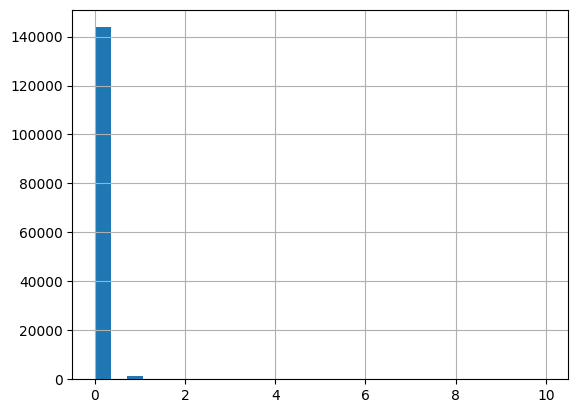

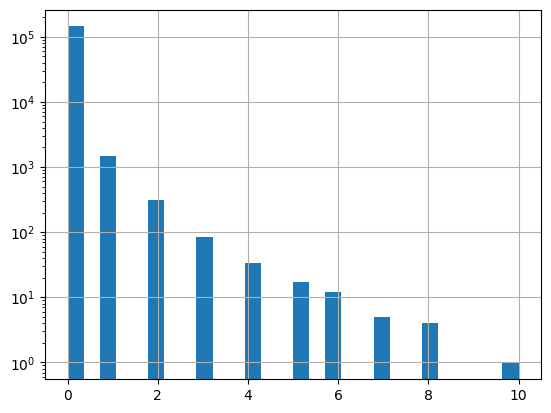

In [24]:
returns_per_customer = (
    transactions["sale_revenue"] < 0
).groupby(transactions["cust_id"]).sum()

returns_per_customer.describe()

#plot distribution of returns per customer
returns_per_customer.hist(bins=28)
plt.show()


#plot distribution of returns per customer with log scale
returns_per_customer.hist(bins=28, log=True)  
plt.show()

# Build Features

In [25]:
# define reference date as the maximum order date in the transactions dataset
reference_date = transactions["order_date"].max()

In [26]:
# identify returns and purchases
transactions["is_return"] = transactions["sale_revenue"] < 0
transactions["is_purchase"] = transactions["sale_revenue"] > 0

In [27]:
# create customer features
customer_features = (
    transactions
    .groupby("cust_id")
    .agg(
        # Monetary
        total_revenue=("sale_revenue", "sum"),
        avg_item_revenue=("sale_revenue", "mean"),
        max_item_revenue=("sale_revenue", "max"),

        # Frequency
        n_orders=("sale_id", "nunique"),
        n_items=("sale_id", "count"),

        # Discounts
        total_discount=("sale_discount_applied", "sum"),

        # Returns
        n_returns=("is_return", "sum"),

        # Product diversity
        n_products=("prod_id", "nunique"),
        n_brands=("prod_brand", "nunique"),
        n_colors=("prod_color", "nunique"),
        n_categories=("prod_type_3", "nunique"),

        # Size behaviour
        avg_size=("prod_size", lambda x: pd.to_numeric(x, errors="coerce").mean()),
        size_std=("prod_size", lambda x: pd.to_numeric(x, errors="coerce").std()),
        n_sizes=("prod_size", "nunique"),

        # Dates
        first_purchase=("order_date", "min"),
        last_purchase=("order_date", "max")
    )
    .reset_index()
)

In [28]:
customer_features["recency_days"] = (
    reference_date - customer_features["last_purchase"]
).dt.days

customer_features["customer_age_days"] = (
    customer_features["last_purchase"] - customer_features["first_purchase"]
).dt.days

customer_features = customer_features.drop(
    columns=["first_purchase", "last_purchase"]
)

In [29]:
customer_features["items_per_order"] = (
    customer_features["n_items"] / customer_features["n_orders"]
)

customer_features["return_rate"] = (
    customer_features["n_returns"] / customer_features["n_items"]
)

customer_features["avg_order_value"] = (
    customer_features["total_revenue"] / customer_features["n_orders"]
)

In [30]:
# inspect the resulting customer features
customer_features.shape



(145739, 20)

In [31]:
customer_features.head()

,cust_id,total_revenue,avg_item_revenue,max_item_revenue,n_orders,n_items,total_discount,n_returns,n_products,n_brands,n_colors,n_categories,avg_size,size_std,n_sizes,recency_days,customer_age_days,items_per_order,return_rate,avg_order_value
0,222agnowc53dykbq,89.95,89.950000,89.95,1,1,0.00,0,1,1,1,1,46.0,NaN,1,383,0,1.0,0.0,89.95
1,222ny4m63rmalpdl,125.93,41.976667,62.97,1,3,-45.16,0,3,2,3,2,38.0,4.358899,3,374,0,3.0,0.0,125.93
2,222wlefm7esnsi3h,157.32,78.660000,79.96,1,2,-28.58,0,2,2,1,2,38.5,0.707107,2,18,0,2.0,0.0,157.32
3,223jend5smd4ptmc,89.95,89.950000,89.95,1,1,0.00,0,1,1,1,1,37.0,NaN,1,488,0,1.0,0.0,89.95
4,223xvc4rbjatlnev,116.14,58.070000,60.17,1,2,-49.76,0,2,1,2,1,37.5,0.707107,2,520,0,2.0,0.0,116.14


In [32]:
customer_features.describe()


,total_revenue,avg_item_revenue,max_item_revenue,n_orders,n_items,total_discount,n_returns,n_products,n_brands,n_colors,n_categories,avg_size,size_std,n_sizes,recency_days,customer_age_days,items_per_order,return_rate,avg_order_value
count,145739.000000,145739.000000,145739.000000,145739.000000,145739.000000,145739.000000,145739.000000,145739.000000,145739.000000,145739.000000,145739.000000,145739.000000,69172.000000,145739.000000,145739.000000,145739.000000,145739.000000,145739.000000,145739.000000
mean,125.354525,61.727821,75.470070,1.687455,2.361839,-48.762668,0.018705,2.232944,1.876979,1.881542,1.652125,37.500479,2.144611,1.606475,297.389635,87.316655,1.336980,0.003641,77.040504
std,119.188366,31.006359,33.668736,1.396445,2.714648,86.754337,0.192901,2.446295,1.718160,1.538348,1.171990,5.087644,2.829216,1.167381,203.597141,167.318981,0.687031,0.036477,42.910299
min,10.000000,1.532500,5.000000,1.000000,1.000000,-3836.910000,0.000000,1.000000,1.000000,1.000000,1.000000,16.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,3.333333
25%,59.300000,39.572250,51.570000,1.000000,1.000000,-57.500000,0.000000,1.000000,1.000000,1.000000,1.000000,36.000000,0.000000,1.000000,138.000000,0.000000,1.000000,0.000000,48.970000
50%,89.900000,56.960000,69.950000,1.000000,1.000000,-22.000000,0.000000,1.000000,1.000000,1.000000,1.000000,38.500000,0.707107,1.000000,258.000000,0.000000,1.000000,0.000000,68.470000
75%,145.250000,77.950000,93.750000,2.000000,3.000000,-7.000000,0.000000,2.000000,2.000000,2.000000,2.000000,40.500000,3.326660,2.000000,459.000000,88.000000,1.500000,0.000000,95.970000
max,1199.040000,275.000000,275.000000,33.000000,142.000000,0.000000,10.000000,131.000000,57.000000,28.000000,14.000000,50.000000,19.091883,22.000000,730.000000,730.000000,28.000000,0.857143,855.950000


# merge train set with features

In [33]:
# merge customer features with train dataset
train_df = train.merge(customer_features, on="cust_id", how="left")
train_df.shape

(116591, 21)

In [34]:
train_df.isna().sum()

cust_id                  0
revenue_2018_2019        0
total_revenue            0
avg_item_revenue         0
max_item_revenue         0
n_orders                 0
n_items                  0
total_discount           0
n_returns                0
n_products               0
n_brands                 0
n_colors                 0
n_categories             0
avg_size                 0
size_std             61306
n_sizes                  0
recency_days             0
customer_age_days        0
items_per_order          0
return_rate              0
avg_order_value          0
dtype: int64

In [35]:
customer_features["size_std"] = customer_features["size_std"].fillna(0)

In [36]:
# sanity check
train_df.describe()

,revenue_2018_2019,total_revenue,avg_item_revenue,max_item_revenue,n_orders,n_items,total_discount,n_returns,n_products,n_brands,n_colors,n_categories,avg_size,size_std,n_sizes,recency_days,customer_age_days,items_per_order,return_rate,avg_order_value
count,116591.000000,116591.000000,116591.000000,116591.000000,116591.000000,116591.000000,116591.000000,116591.000000,116591.000000,116591.000000,116591.000000,116591.000000,116591.000000,55285.000000,116591.000000,116591.000000,116591.000000,116591.000000,116591.000000,116591.000000
mean,70.364667,125.395456,61.833516,75.555169,1.685988,2.360096,-48.638204,0.018595,2.231990,1.877461,1.882135,1.651422,37.514185,2.138870,1.605458,297.186798,87.251074,1.337300,0.003661,77.145728
std,144.303602,118.940476,31.073269,33.668081,1.391940,2.698021,86.492093,0.189792,2.439056,1.717616,1.538756,1.171298,5.075662,2.821502,1.165707,203.258925,167.209245,0.688748,0.036619,42.894510
min,0.000000,10.000000,1.532500,5.000000,1.000000,1.000000,-3836.910000,0.000000,1.000000,1.000000,1.000000,1.000000,16.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,3.333333
25%,0.000000,59.300000,39.715000,51.950000,1.000000,1.000000,-57.500000,0.000000,1.000000,1.000000,1.000000,1.000000,36.000000,0.000000,1.000000,138.000000,0.000000,1.000000,0.000000,48.970000
50%,0.000000,89.940000,56.966667,69.950000,1.000000,1.000000,-22.000000,0.000000,1.000000,1.000000,1.000000,1.000000,38.500000,0.707107,1.000000,258.000000,0.000000,1.000000,0.000000,68.680000
75%,80.960000,145.390000,78.000000,94.500000,2.000000,3.000000,-6.990000,0.000000,2.000000,2.000000,2.000000,2.000000,40.500000,3.304038,2.000000,457.000000,88.000000,1.500000,0.000000,96.000000
max,1197.940000,1199.040000,275.000000,275.000000,26.000000,142.000000,0.000000,10.000000,131.000000,57.000000,28.000000,14.000000,50.000000,19.091883,22.000000,730.000000,730.000000,28.000000,0.857143,855.950000


In [37]:
train_df.corr(numeric_only=True)["revenue_2018_2019"].sort_values(ascending=False)

revenue_2018_2019    1.000000
total_revenue        0.441262
n_orders             0.434242
n_categories         0.427451
n_products           0.424570
n_colors             0.421737
n_items              0.412661
n_brands             0.408940
n_sizes              0.381446
customer_age_days    0.362576
max_item_revenue     0.166951
size_std             0.151301
items_per_order      0.139500
n_returns            0.084696
avg_order_value      0.076762
return_rate          0.039846
avg_item_revenue    -0.046804
avg_size            -0.100748
recency_days        -0.211561
total_discount      -0.269022
Name: revenue_2018_2019, dtype: float64

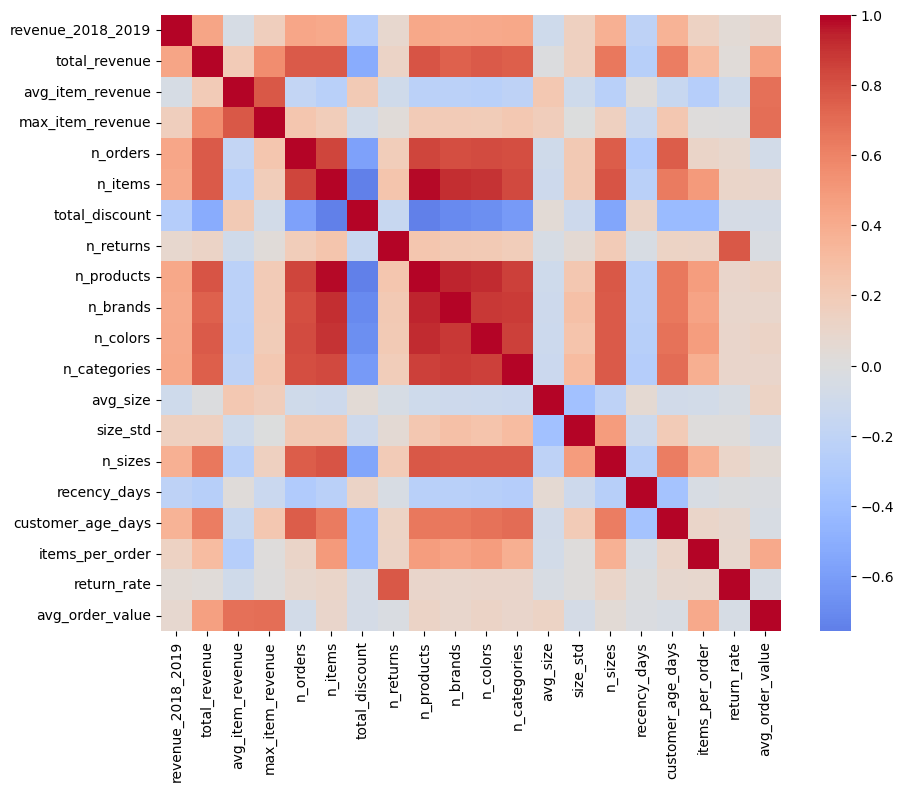

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(
    train_df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0
)
plt.show()

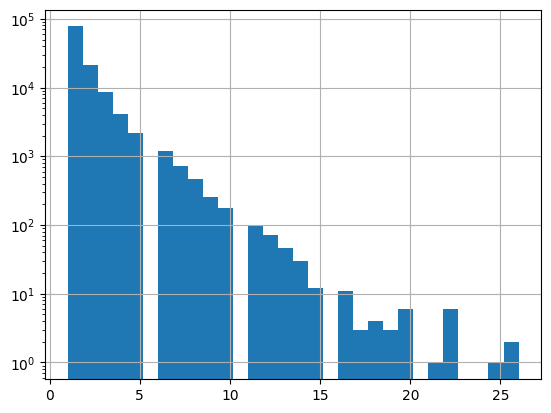

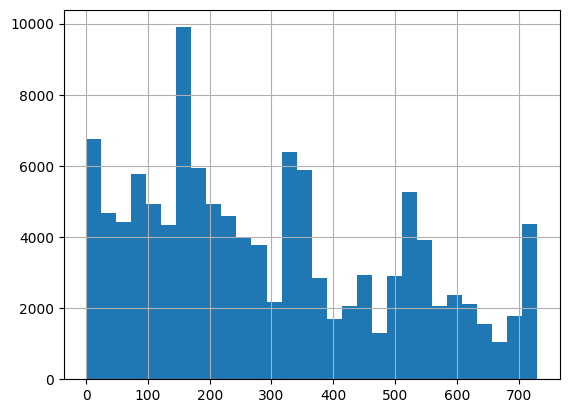

In [39]:
train_df["n_orders"].hist(bins=30,log=True)
plt.show()

train_df["recency_days"].hist(bins=30)
plt.show()

In [40]:
train_df["revenue_2018_2019"].describe()


count    116591.000000
mean         70.364667
std         144.303602
min           0.000000
25%           0.000000
50%           0.000000
75%          80.960000
max        1197.940000
Name: revenue_2018_2019, dtype: float64

In [41]:
# set target
train_df["returned_customer"] = (train_df["revenue_2018_2019"] > 0).astype(int)

# Training split

In [42]:
features = train_df.drop(columns=["cust_id","revenue_2018_2019","returned_customer"])

In [43]:
y_reg = train_df["revenue_2018_2019"]
y_cls = train_df["returned_customer"]

In [44]:
#training/validation split
from sklearn.model_selection import train_test_split

X_train, X_val, y_train_reg, y_val_reg, y_train_cls, y_val_cls = train_test_split(
    features,
    y_reg,
    y_cls,
    test_size=0.2,
    random_state=42
)

# model 1: light GBM

In [45]:
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error

In [46]:
model = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=-1,
    random_state=42
)

model.fit(X_train, y_train_reg)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003647 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2632
[LightGBM] [Info] Number of data points in the train set: 93272, number of used features: 19
[LightGBM] [Info] Start training from score 70.306075


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,500
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [47]:
val_preds = model.predict(X_val)

In [48]:
mae = mean_absolute_error(y_val_reg, val_preds)
print("Validation MAE:", mae)

Validation MAE: 77.17280734736285


In [49]:
importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

importance.head(10)

,feature,importance
14,recency_days,1537
11,avg_size,1349
15,customer_age_days,1340
12,size_std,1312
0,total_revenue,1303
5,total_discount,1285
2,max_item_revenue,1256
1,avg_item_revenue,1137
18,avg_order_value,978
16,items_per_order,602


# Model 2: two part predictor- first return, then revenue

## probability of returning

In [50]:
import lightgbm as lgb

clf = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

clf.fit(X_train, y_train_cls)

p_return = clf.predict_proba(X_val)[:, 1]

[LightGBM] [Info] Number of positive: 34106, number of negative: 59166
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004105 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2632
[LightGBM] [Info] Number of data points in the train set: 93272, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.365662 -> initscore=-0.550874
[LightGBM] [Info] Start training from score -0.550874


## revenue given returns    

In [51]:
X_train_return = X_train[y_train_reg > 0]
y_train_return = y_train_reg[y_train_reg > 0]

# log of revenue to deal with skewness

y_train_return_log = np.log1p(y_train_return)

reg = lgb.LGBMRegressor(
    n_estimators=500,
    learning_rate=0.05,
    random_state=42
)

reg.fit(X_train_return, y_train_return_log)

log_rev_pred = reg.predict(X_val)

rev_pred = np.expm1(log_rev_pred)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001846 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2631
[LightGBM] [Info] Number of data points in the train set: 34106, number of used features: 19
[LightGBM] [Info] Start training from score 4.900509


## combine models to predict

In [52]:
final_preds = p_return * rev_pred

## evaluate model

In [53]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_val_reg, final_preds)
print("Two-stage MAE:", mae)

Two-stage MAE: 71.96349379339398


In [54]:
from scipy.stats import spearmanr

spearman_corr, _ = spearmanr(y_val_reg, final_preds)

print("Spearman correlation:", spearman_corr)

Spearman correlation: 0.39307968097176


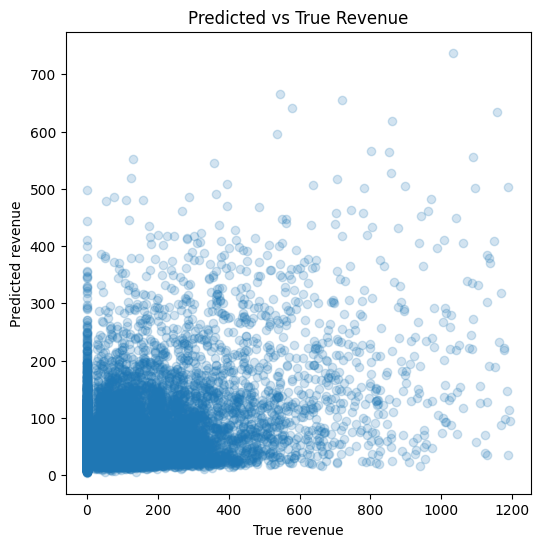

In [55]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(6,6))

plt.scatter(y_val_reg, final_preds, alpha=0.2)

plt.xlabel("True revenue")
plt.ylabel("Predicted revenue")

plt.title("Predicted vs True Revenue")

plt.show()

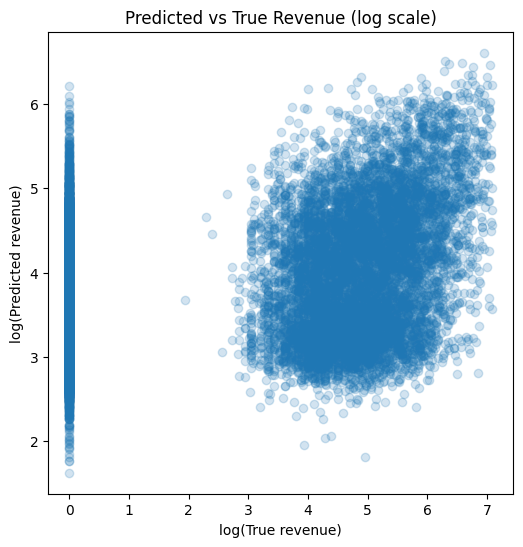

In [56]:
plt.figure(figsize=(6,6))

plt.scatter(
    np.log1p(y_val_reg),
    np.log1p(final_preds),
    alpha=0.2
)

plt.xlabel("log(True revenue)")
plt.ylabel("log(Predicted revenue)")

plt.title("Predicted vs True Revenue (log scale)")

plt.show()

too many non returners being predicted to spedn. Introduce a probability threshold for returning

In [57]:
for t in [0.1, 0.15, 0.2, 0.25, 0.3]:
    preds = np.where(p_return < t, 0, p_return * rev_pred)
    mae = mean_absolute_error(y_val_reg, preds)
    print(t, mae)

0.1 71.94931695561037
0.15 71.74937359920999
0.2 70.25311022344214
0.25 67.23086861028219
0.3 65.18321179928962


In [58]:
spearman_corr, _ = spearmanr(y_val_reg, preds)
print("Spearman:", spearman_corr)

Spearman: 0.4065743678056509


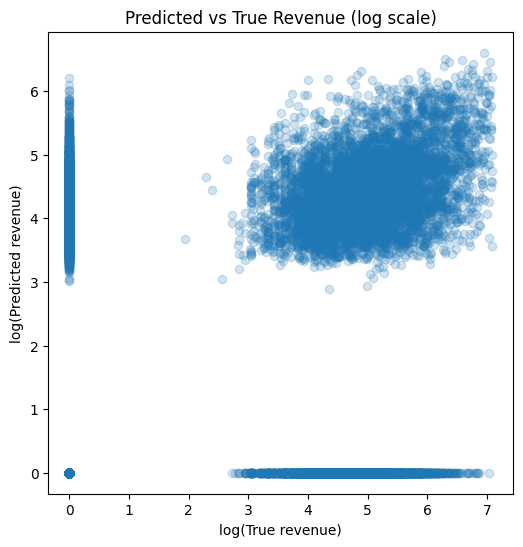

In [59]:
plt.figure(figsize=(6,6))

plt.scatter(
    np.log1p(y_val_reg),
    np.log1p(preds),
    alpha=0.2
)

plt.xlabel("log(True revenue)")
plt.ylabel("log(Predicted revenue)")

plt.title("Predicted vs True Revenue (log scale)")

plt.show()